In [21]:
import re
import os
import pickle
import pandas as pd
from charset_normalizer import detect
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings("ignore")

## 1. Data Cleaning

In [ ]:
import os
import re
from bs4 import BeautifulSoup
from chardet import detect

# Dictionary to store the first paragraph text from each HTML file
first_paragraph_texts = {}

def read_html_files_with_encoding(base_folder):
    """
    Recursively read HTML files from a folder, extract the content of the first <p> tag,
    and skip any folder named 'index'.
    
    :param base_folder: The top-level folder path to scan
    :return: A dictionary containing file names as keys and the first <p> text content as values
    """
    for root, dirs, files in os.walk(base_folder):
        # Skip directories named 'index'
        if 'index' in dirs:
            dirs.remove('index')  # Remove 'index' folder from traversal

        for file_name in files:
            # Process only HTML files
            if file_name.lower().endswith(('.html', '.htm')):  
                file_path = os.path.join(root, file_name)  # Construct the full file path

                # Auto-detect file encoding
                with open(file_path, 'rb') as file:
                    raw_data = file.read()
                    result = detect(raw_data)
                    encoding = result['encoding']

                # Read HTML file content using detected encoding
                with open(file_path, 'r', encoding=encoding) as file:
                    html_content = file.read()
                
                # Parse HTML content using BeautifulSoup
                soup = BeautifulSoup(html_content, 'html.parser')
                
                # Extract content from all <p> tags
                paragraph_list = soup.find_all('p')
                first_paragraph = ''
                for i in range(len(paragraph_list)):
                    first_paragraph = first_paragraph + ' ' + paragraph_list[i].get_text()
                    # Remove extra whitespace
                    first_paragraph = re.sub(r'\s{2,}', ' ', first_paragraph)
                    word_count = len(first_paragraph.split())
                    # Stop once the first paragraph has at least 20 words
                    if word_count >= 20:
                        break
                
                # Store the first paragraph content with the file name as key
                first_paragraph_texts[file_name] = first_paragraph
                    

    return first_paragraph_texts

# Example: Read the first <p> tag content from HTML files in a given folder
folder_path = "D://Study//Classes-M1//ADA//Milestone1 Data Cleaned//wpcd//wp"
html_files = read_html_files_with_encoding(folder_path)


In [ ]:
import pickle

# Extract the first paragraph from each HTML file
processed_files = {}

for file_name, content in html_files.items():
    # Remove the file extension, split by the last '.' character
    base_name = file_name.rsplit('.', 1)[0]  # Keep only the main file name
    
    # Strip leading and trailing spaces from the content
    cleaned_sentence = content.strip(' ')

    # Store the processed content into a new dictionary
    processed_files[base_name] = cleaned_sentence

# Save the processed data to a pickle file
processed_file_name = 'new_data_cleaning//new_text_data.pkl'
with open(processed_file_name, "wb") as f:
    pickle.dump(processed_files, f)

## 2. Embedding

In [23]:
import argparse
import os
import pickle
from datetime import datetime
from glob import glob

from tqdm import tqdm
from src.semantic.utils.embedding_models import All_MiniLM_L6_v2, Roberta, all_mpnet_base_v2

In [6]:
model = All_MiniLM_L6_v2()
All_MiniLM_Embeddings = {}
for file_name, content in processed_files.items():
    embedding = model.embed(content)
    All_MiniLM_Embeddings[file_name] = embedding

In [7]:
model = all_mpnet_base_v2()
all_mpnet_Embeddings = {}
for file_name, content in processed_files.items():
    embedding = model.embed(content)
    all_mpnet_Embeddings[file_name] = embedding

In [24]:
model = Roberta()
Roberta_Embeddings = {}
for file_name, content in processed_files.items():
    embedding = model.embed(content)
    Roberta_Embeddings[file_name] = embedding

In [ ]:
print(len(All_MiniLM_Embeddings))
print(len(All_MiniLM_Embeddings['10th_century']))
print(len(all_mpnet_Embeddings['10th_century']))
print(len(Roberta_Embeddings['10th_century']))

1024


In [ ]:
# Use the same concepts selected in the previous cleaned data
# All paths to the embedding data files
MiniLM_file = 'data//semantic//output//embeddings//all_MiniLM_L6_v2.pkl' 
mpnet_file = 'data//semantic//output//embeddings//all_mpnet_base_v2.pkl' 
roberta_file = 'data//semantic//output//embeddings//roberta.pkl' 

# Load embedding files
with open(MiniLM_file, "rb") as file:
    MiniLM_orgin = pickle.load(file)
with open(mpnet_file, "rb") as file:
    mpnet_orgin = pickle.load(file)
with open(roberta_file, "rb") as file:
    roberta_orgin = pickle.load(file)

# Filter concepts: keep keys from dict1 that also exist in dict2
All_MiniLM_Embeddings = {k: v for k, v in All_MiniLM_Embeddings.items() if k in MiniLM_orgin}
all_mpnet_Embeddings = {k: v for k, v in all_mpnet_Embeddings.items() if k in mpnet_orgin}
Roberta_Embeddings = {k: v for k, v in Roberta_Embeddings.items() if k in roberta_orgin}

# Save filtered embeddings
new_MiniLM_file = 'new_data_cleaning//new_MiniLM_embedding.pkl'
new_mpnet_file = 'new_data_cleaning//new_mpnet_embedding.pkl'
new_Roberta_file = 'new_data_cleaning//new_Roberta_embedding.pkl'
with open(new_MiniLM_file, "wb") as f:
    pickle.dump(All_MiniLM_Embeddings, f)
with open(new_mpnet_file, "wb") as f:
    pickle.dump(all_mpnet_Embeddings, f)
with open(new_Roberta_file, "wb") as f:
    pickle.dump(Roberta_Embeddings, f)


## 3. PCA

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def pca_reduce_embeddings(embedding_vector, pca_model):
    # Reshape 1D array to 2D array (1, num_dimensions) for PCA processing
    embedding_reshaped = embedding_vector.reshape(1, -1)
    # Apply PCA model to reduce dimensions
    reduced_embedding = pca_model.transform(embedding_reshaped)
    # Return the 1D array (reduced dimensions)
    return reduced_embedding.flatten()


def plot_variance(pca_model, title="Explained Variance"):
    """
    Plot the explained variance and cumulative explained variance.
    """
    explained_variance_ratio = pca_model.explained_variance_ratio_
    cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

    plt.figure(figsize=(8, 5))
    plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, align='center', label='Individual explained variance')
    plt.step(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, where='mid', label='Cumulative explained variance')
    plt.xlabel('Principal Component Index')
    plt.ylabel('Explained Variance Ratio')
    plt.title(title)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()


# Function to perform PCA dimensionality reduction and plot variance
def perform_pca_and_plot(embeddings, target_dim=200):
    """
    Perform PCA and visualize explained variance and cumulative explained variance.
    """
    embedding_matrix = np.array(list(embeddings.values()))
    pca_model = PCA(n_components=target_dim)
    pca_model.fit(embedding_matrix)

    # Plot the explained variance graph
    plot_variance(pca_model, title="PCA Explained Variance")

    # Determine the optimal number of principal components to retain 70% variance
    cumulative_variance_ratio = np.cumsum(pca_model.explained_variance_ratio_)
    optimal_components = np.argmax(cumulative_variance_ratio >= 0.70) + 1
    print(f"Number of components to retain 70% variance: {optimal_components}")

    # Return the PCA model and the number of optimal components
    return pca_model, optimal_components

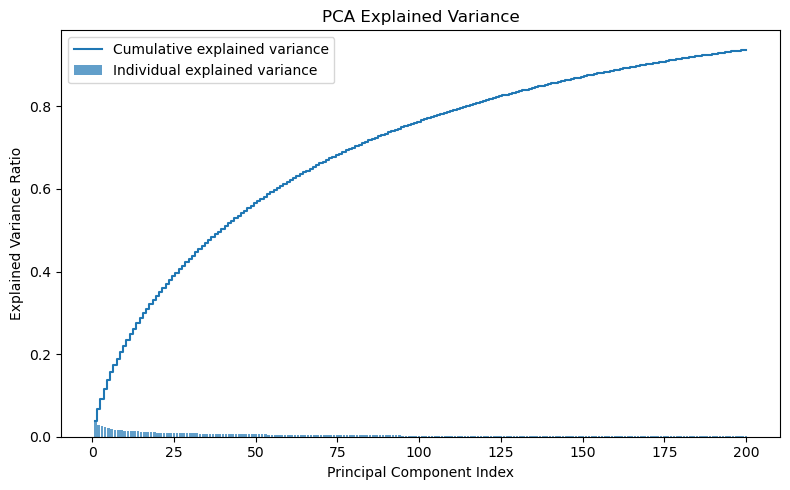

Number of components to retain 70% variance: 80


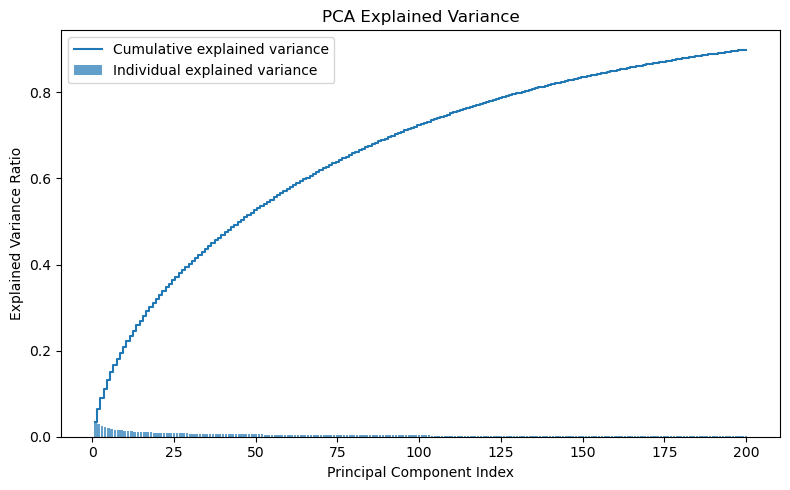

Number of components to retain 70% variance: 93


In [ ]:
# PCA for All_MiniLM_Embeddings
embedding_matrix = np.array(list(All_MiniLM_Embeddings.values()))
pca_model_MiniLM, optimal_components_MiniLM = perform_pca_and_plot(All_MiniLM_Embeddings, target_dim=200)

# Update PCA model and set the optimal number of dimensions
pca_model_MiniLM = PCA(n_components=optimal_components_MiniLM)
pca_model_MiniLM.fit(embedding_matrix)

# Create an empty dictionary to store the reduced embeddings
pca_MiniLM = {}
for key, embedding in All_MiniLM_Embeddings.items():
    reduced_embedding = pca_reduce_embeddings(embedding, pca_model_MiniLM)
    pca_MiniLM[key] = reduced_embedding


# PCA for all_mpnet_Embeddings
embedding_matrix = np.array(list(all_mpnet_Embeddings.values()))
pca_model_mpnet, optimal_components_mpnet = perform_pca_and_plot(all_mpnet_Embeddings, target_dim=200)

# Update PCA model and set the optimal number of dimensions
pca_model_mpnet = PCA(n_components=optimal_components_mpnet)
pca_model_mpnet.fit(embedding_matrix)

# Create an empty dictionary to store the reduced embeddings
pca_mpnet = {}
for key, embedding in all_mpnet_Embeddings.items():
    reduced_embedding = pca_reduce_embeddings(embedding, pca_model_mpnet)
    pca_mpnet[key] = reduced_embedding

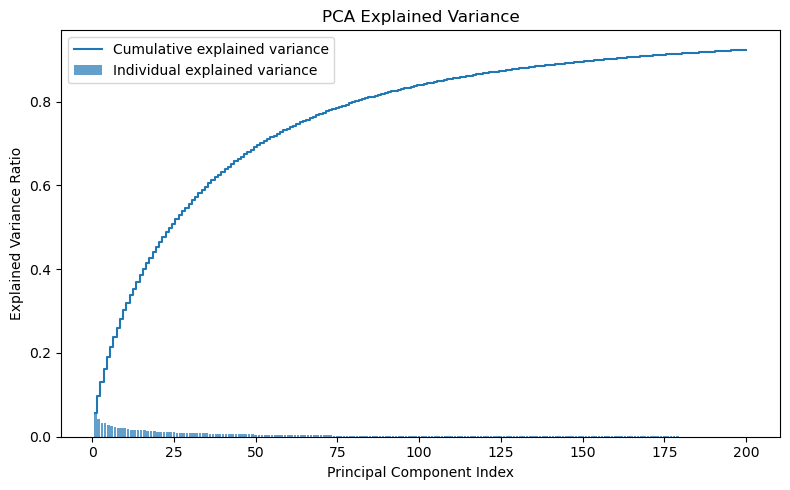

Number of components to retain 70% variance: 52


In [ ]:
# PCA for Roberta_Embeddings
embedding_matrix = np.array(list(Roberta_Embeddings.values()))
pca_model_mpnet, optimal_components_mpnet = perform_pca_and_plot(Roberta_Embeddings, target_dim=200)

# Update the PCA model and set the optimal number of dimensions
pca_model_mpnet = PCA(n_components=optimal_components_mpnet)
pca_model_mpnet.fit(embedding_matrix)

# Create an empty dictionary to store the reduced embeddings
pca_roberta = {}
for key, embedding in Roberta_Embeddings.items():
    reduced_embedding = pca_reduce_embeddings(embedding, pca_model_mpnet)
    pca_roberta[key] = reduced_embedding

In [ ]:
print(len(pca_MiniLM['%C3%81ed%C3%A1n_mac_Gabr%C3%A1in']))
print(len(pca_mpnet['%C3%81ed%C3%A1n_mac_Gabr%C3%A1in']))
print(len(pca_roberta['%C3%81ed%C3%A1n_mac_Gabr%C3%A1in']))

80
93


In [ ]:
# Save the data
pca_MiniLM_file = 'new_data_cleaning//pca_MiniLM_dimensions.pkl'
pca_mpnet_file = 'new_data_cleaning//pca_mpnet_dimensions.pkl'
pca_Roberta_file = 'new_data_cleaning//pca_Roberta_dimensions.pkl'
with open(pca_MiniLM_file, "wb") as f:
    pickle.dump(pca_MiniLM, f)
with open(pca_mpnet_file, "wb") as f:
    pickle.dump(pca_mpnet, f)
with open(pca_Roberta_file, "wb") as f:
    pickle.dump(pca_roberta, f)

### 3. TF-IDF

In [ ]:
# Filter the existing text data to retain only concepts present in the previous data
processed_files = {k: v for k, v in processed_files.items() if k in MiniLM_orgin}
len(processed_files)

4604

In [ ]:
processed_file_name = 'new_data_cleaning//new_text_data.pkl'
with open(processed_file_name, "wb") as f:
    pickle.dump(processed_files, f)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords, words
import nltk
import pandas as pd
import re

# Download NLTK stopwords and English words vocabulary
nltk.download("stopwords")
nltk.download("words")

# Initialize stemming and stop words
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

# Get English words vocabulary (optional)
english_vocab = set(words.words())

# Preprocessing function: Stemming, removing stop words, and non-English words
def preprocess_text(text):
    # Split the text into words
    words = text.split()
    # Filter out stop words, non-English words, and apply stemming
    filtered_words = [
        stemmer.stem(word) for word in words
        if word.lower() not in stop_words  # Remove stop words
        and re.match("^[a-zA-Z]+$", word)  # Check if the word is purely alphabetical
    ]
    return " ".join(filtered_words)

# Preprocess all text in the dictionary
preprocessed_data = {key: preprocess_text(value) for key, value in processed_files.items()}

# Extract keys and preprocessed texts
keys = list(preprocessed_data.keys())
texts = list(preprocessed_data.values())

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer()

# Generate the TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(texts)

# Convert the matrix to a DataFrame for easier inspection
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=keys, columns=vectorizer.get_feature_names_out())

# Print the resulting DataFrame
print(tfidf_df)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sugar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\sugar\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


                                   aa  aaa  aaab  aab  aaby  aac  aachen  aad  \
%C3%81ed%C3%A1n_mac_Gabr%C3%A1in  0.0  0.0   0.0  0.0   0.0  0.0     0.0  0.0   
%C3%85land                        0.0  0.0   0.0  0.0   0.0  0.0     0.0  0.0   
%C3%89douard_Manet                0.0  0.0   0.0  0.0   0.0  0.0     0.0  0.0   
%C3%89ire                         0.0  0.0   0.0  0.0   0.0  0.0     0.0  0.0   
%C3%93engus_I_of_the_Picts        0.0  0.0   0.0  0.0   0.0  0.0     0.0  0.0   
...                               ...  ...   ...  ...   ...  ...     ...  ...   
Zirconium                         0.0  0.0   0.0  0.0   0.0  0.0     0.0  0.0   
Zoroaster                         0.0  0.0   0.0  0.0   0.0  0.0     0.0  0.0   
Zuid-Gelders                      0.0  0.0   0.0  0.0   0.0  0.0     0.0  0.0   
Zulu                              0.0  0.0   0.0  0.0   0.0  0.0     0.0  0.0   
ZX_Spectrum                       0.0  0.0   0.0  0.0   0.0  0.0     0.0  0.0   

                           

In [ ]:
tfidf_file = 'new_data_cleaning//tfidf.csv'
tfidf_df.to_csv(tfidf_file,index=False,encoding='utf-8-sig')